In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.0 MB/s eta 0:00:00


# 1. Import Libraries

In [170]:
import pandas as pd
import torch
from torch import optim
from torchmetrics import Accuracy, F1Score, ConfusionMatrix
from torch.utils.data import Dataset, DataLoader
import yaml
from torch import nn
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR

from tqdm import tqdm

import matplotlib.pyplot as plt

import random
import os

In [158]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

## 2. Building MLP

In [159]:
def label_dict_from_config_file(relative_path):
    with open(relative_path,"r") as f:
       label_tag = yaml.full_load(f)["gestures"]
    return label_tag

In [160]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.flatten = nn.Flatten()
    list_labels = label_dict_from_config_file("hand_gesture.yaml")

    self.linear_relu_stack = nn.Sequential(

        # Layer 1
        nn.Linear(63, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.15),

        # Layer 2
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.15),

        # Output layer
        nn.Linear(32, len(list_labels))
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

  def predict(self, x, threshold = 0.8):
    logits = self(x)
    softmax_prob = nn.Softmax(dim=1)(logits)
    chosen_id = torch.argmax(softmax_prob, dim = 1)
    return torch.where(softmax_prob[0, chosen_id] > threshold, chosen_id, -1)

  def predict_with_known_class(self, x):
    logits = self(x)
    softmax_prob = nn.Softmax(dim=1)(logits)
    return torch.argmax(softmax_prob, dim = 1)

  def score(self, logits):
    return -torch.amax(logits, dim = 1)

# 3. Load Dataset

In [161]:
class CustomImageDataset(Dataset):
    def __init__(self, data_file, is_train=False):
        self.data = pd.read_csv(data_file)
        self.labels = torch.from_numpy(self.data.iloc[:, 0].to_numpy())
        self.is_train = is_train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label = self.labels[idx]

        raw_features = self.data.iloc[idx, 1:].to_numpy(dtype=np.float32)

        coords = raw_features.reshape(21, 3)

        wrist_coord = coords[0]

        relative_coords = coords - wrist_coord

        distances = np.sqrt(np.sum(relative_coords ** 2, axis=1))
        max_distance = np.max(distances)

        if max_distance > 0:
            relative_coords = relative_coords / max_distance

        if self.is_train:
            noise = np.random.normal(0, 0.005, relative_coords.shape).astype(np.float32)
            relative_coords = relative_coords + noise

        normalized_features = relative_coords.flatten()
        torch_data = torch.from_numpy(normalized_features)

        return torch_data, label

In [162]:
train_set = CustomImageDataset("/content/landmark_train.csv", is_train=True)
val_set = CustomImageDataset("/content/landmark_val.csv", is_train=False)
test_set = CustomImageDataset("/content/landmark_test.csv", is_train=False)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=50, shuffle=False)
test_loader = DataLoader(test_set, batch_size=20, shuffle=False)

# 4. Define Early Stopping Class

In [163]:
class EarlyStopper:
  def __init__(self, patience = 1, min_delta = 0):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.watched_metrics = np.inf

  def early_stop(self, current_value):
    if current_value < self.watched_metrics:
      self.watched_metrics = current_value
      self.counter = 0

    elif current_value > (self.watched_metrics + self.min_delta):
      self.counter += 1
      if self.counter >= self.patience:
        return True

    return False


# 5. Training

In [164]:
model = NeuralNetwork()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
early_stopper = EarlyStopper(patience=10, min_delta=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

In [165]:
def train(
    train_loader,
    val_loader,
    model,
    loss_function,
    early_stopper,
    optimizer,
    device='cpu'
):

    best_vloss = np.inf
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(300):

        # TRAIN MODE
        model.train()
        running_loss = 0.0

        acc_train = Accuracy(
            num_classes=len(LIST_LABEL),
            task='multiclass'
        ).to(device)

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            preds = model(inputs)
            loss = loss_function(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pred_classes = torch.argmax(preds, dim=1)
            acc_train.update(pred_classes, labels)

        avg_loss = running_loss / len(train_loader)
        train_acc = acc_train.compute().item()

        train_losses.append(avg_loss)
        train_accs.append(train_acc)

        # VALIDATION MODE
        model.eval()
        running_vloss = 0.0

        acc_val = Accuracy(
            num_classes=len(LIST_LABEL),
            task='multiclass'
        ).to(device)

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                preds = model(inputs)
                vloss = loss_function(preds, labels)

                running_vloss += vloss.item()

                pred_classes = torch.argmax(preds, dim=1)
                acc_val.update(pred_classes, labels)

        avg_vloss = running_vloss / len(val_loader)
        val_acc = acc_val.compute().item()

        val_losses.append(avg_vloss)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {avg_loss:.4f} | Val Loss: {avg_vloss:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        scheduler.step()

        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            torch.save(model.state_dict(), "best_model.pth")

        if early_stopper.early_stop(avg_vloss):
            print("Early stopping triggered.")
            break

    torch.save(model.state_dict(), "last_model.pth")

    return model, train_losses, val_losses, train_accs, val_accs

In [166]:
LIST_LABEL = label_dict_from_config_file("hand_gesture.yaml")

model, train_losses, val_losses, train_acc, val_acc = train(
    train_loader,
    val_loader,
    model,
    loss_function,
    early_stopper,
    optimizer
)

100%|██████████| 21/21 [00:00<00:00, 37.23it/s]



Epoch 1
Train Loss: 1.5066 | Val Loss: 1.5294
Train Acc: 0.3552 | Val Acc: 0.4318


100%|██████████| 21/21 [00:00<00:00, 37.26it/s]



Epoch 2
Train Loss: 1.0624 | Val Loss: 1.1656
Train Acc: 0.7692 | Val Acc: 0.6840


100%|██████████| 21/21 [00:00<00:00, 37.01it/s]


...


Epoch 60
Train Loss: 0.0531 | Val Loss: 0.0750
Train Acc: 0.9892 | Val Acc: 0.9784


100%|██████████| 21/21 [00:00<00:00, 36.22it/s]



Epoch 61
Train Loss: 0.0554 | Val Loss: 0.0833
Train Acc: 0.9889 | Val Acc: 0.9767


100%|██████████| 21/21 [00:00<00:00, 37.54it/s]



Epoch 62
Train Loss: 0.0574 | Val Loss: 0.1120
Train Acc: 0.9854 | Val Acc: 0.9665
Early stopping triggered.


# 6. Evaluation

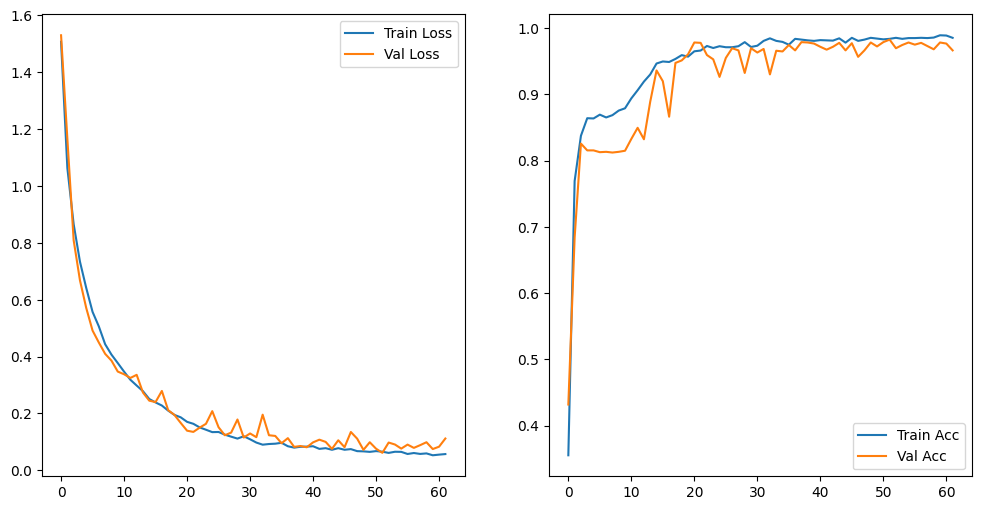

In [167]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(train_losses, label="Train Loss")
ax[0].plot(val_losses, label="Val Loss")
ax[0].legend()

ax[1].plot(train_acc, label="Train Acc")
ax[1].plot(val_acc, label="Val Acc")
ax[1].legend()
plt.show()


# 6.1 Evaluation on Test set

In [175]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_model = NeuralNetwork()

model_path = "/content/best_model.pth"
state_dict = torch.load(model_path, map_location=device, weights_only=True)
test_model.load_state_dict(state_dict)
test_model.to(device)

test_model.eval()

list_label = label_dict_from_config_file("hand_gesture.yaml")
acc_test = Accuracy(num_classes=len(list_label), task='MULTICLASS').to(device)
f1_test = F1Score(num_classes=len(list_label), task='MULTICLASS', average='macro').to(device)
conf_matrix = ConfusionMatrix(num_classes=len(list_label), task='MULTICLASS').to(device)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = test_model(inputs)
        _, preds = torch.max(outputs, 1)

        acc_test.update(preds, labels)
        f1_test.update(preds, labels)
        conf_matrix.update(preds, labels)

print(f"Accuracy: {acc_test.compute().item() * 100:.2f}%")
print(f"Macro F1-Score: {f1_test.compute().item() * 100:.2f}%")

cm = conf_matrix.compute().cpu().numpy()
print("\n--- Confusion Matrix ---")
print(cm)

Accuracy: 95.37%
Macro F1-Score: 95.21%

--- Confusion Matrix ---
[[283   0   0   0   0]
 [  1 312   1   0   0]
 [  0   0 303   4   0]
 [  0   0  67 241   0]
 [  0   0   0   0 366]]
